# Homework 2, Question 4: Feature Transformations

Complete `polynomial_features` and `fourier_features` in `utils.py`, then run the cells below. **Do not change `LAMBDA`**; all ridge fits in this problem use the same regularization strength.

In [45]:
import numpy as np
import pandas as pd
import sklearn.linear_model
import importlib
import warnings
import scipy.linalg
import utils

importlib.reload(utils)  # picks up edits to utils.py without restarting the kernel
warnings.filterwarnings("ignore", category=scipy.linalg.LinAlgWarning)  # high-degree polynomial features are ill-conditioned

LAMBDA = 1.0  # ridge regularization strength, fixed for the whole problem

df = pd.read_csv("Q4.csv")
X, Y = df.X.values[:, np.newaxis], df.Y.values

The polynomial and Fourier models are fit with `fit_intercept=True`: the intercept is fit separately and is **not** penalized, which is why neither feature map includes a constant feature.

## (a) Ordinary least squares baseline

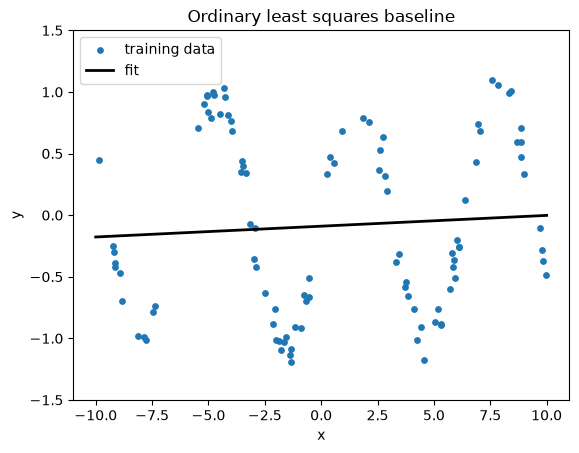

In [28]:
h_lin = sklearn.linear_model.LinearRegression().fit(X, Y)
utils.plot_data_and_fit(X, Y, h_lin.predict, -10, 10, title="Ordinary least squares baseline")

## (b), (c) Ridge regression with polynomial features

For part (c), change `D` and rerun.

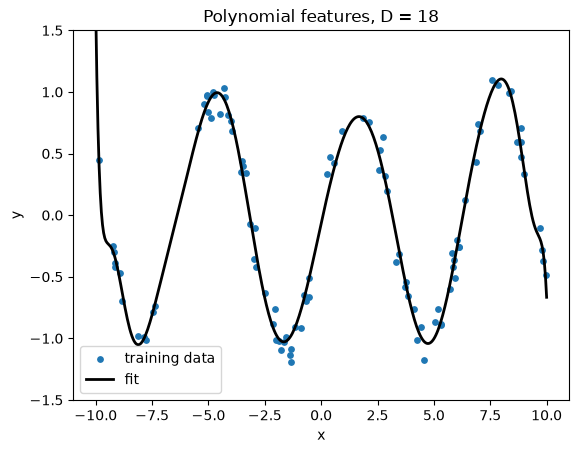

In [62]:
D = 18
h_poly = sklearn.linear_model.Ridge(alpha=LAMBDA, fit_intercept=True).fit(utils.polynomial_features(X, D), Y)
poly_pred = lambda x: h_poly.predict(utils.polynomial_features(x, D))
utils.plot_data_and_fit(X, Y, poly_pred, -10, 10, title=f"Polynomial features, D = {D}")

## (d), (e) Ridge regression with Fourier features

For part (e), change `J` or `T` and rerun.

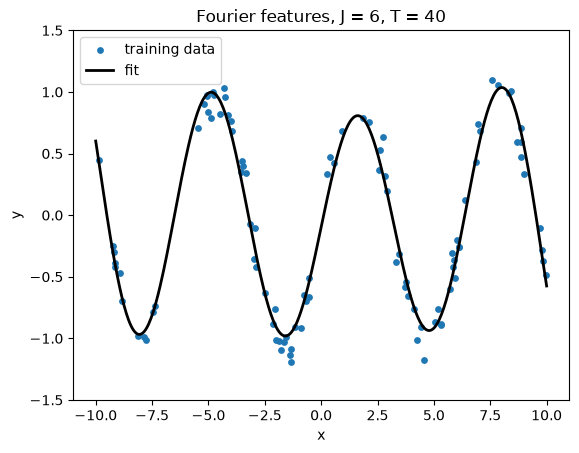

In [75]:
J = 6
T = 40
h_four = sklearn.linear_model.Ridge(alpha=LAMBDA, fit_intercept=True).fit(utils.fourier_features(X, J, T), Y)
four_pred = lambda x: h_four.predict(utils.fourier_features(x, J, T))
utils.plot_data_and_fit(X, Y, four_pred, -10, 10, title=f"Fourier features, J = {J}, T = {T}")

## (f) Extrapolation

Each dataset has training data on $[-10, 10]$ and future data on $10 < |x| \le 20$. Dataset B's training data is the same data used in parts (a)-(e). Do not change the settings in this cell.

Dataset A
  ordinary least squares training MSE = 0.552   future MSE = 1.12
  polynomial, D=10       training MSE = 0.0125   future MSE = 3.05e+08
  Fourier, J=10, T=20    training MSE = 0.00614   future MSE = 0.0145


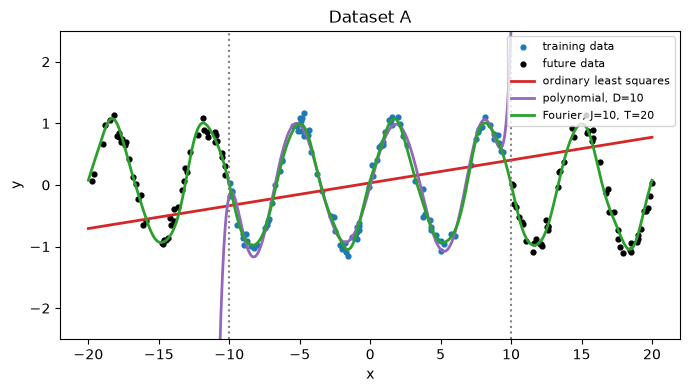

Dataset B
  ordinary least squares training MSE = 0.504   future MSE = 0.19
  polynomial, D=10       training MSE = 0.0317   future MSE = 1.8e+08
  Fourier, J=10, T=20    training MSE = 0.0126   future MSE = 0.461


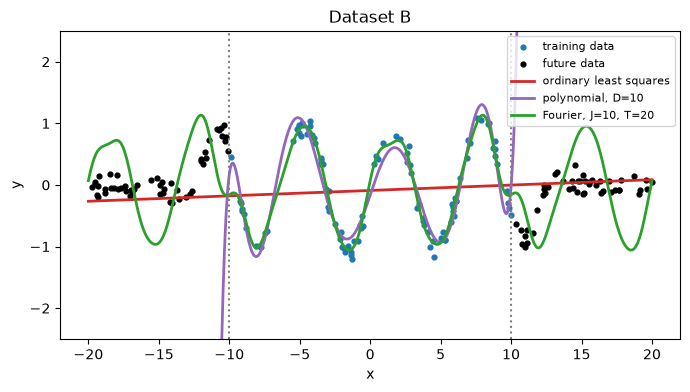

In [59]:
ext = pd.read_csv("Q4f.csv")

def fit_three(X_tr, Y_tr):
    lin = sklearn.linear_model.LinearRegression().fit(X_tr, Y_tr)
    poly = sklearn.linear_model.Ridge(alpha=LAMBDA, fit_intercept=True).fit(utils.polynomial_features(X_tr, 10), Y_tr)
    four = sklearn.linear_model.Ridge(alpha=LAMBDA, fit_intercept=True).fit(utils.fourier_features(X_tr, 10, 20), Y_tr)
    return {
        "ordinary least squares": lin.predict,
        "polynomial, D=10": lambda x: poly.predict(utils.polynomial_features(x, 10)),
        "Fourier, J=10, T=20": lambda x: four.predict(utils.fourier_features(x, 10, 20)),
    }

for name in ["A", "B"]:
    tr = ext[(ext.dataset == name) & (ext.split == "train")]
    fu = ext[(ext.dataset == name) & (ext.split == "future")]
    X_tr, Y_tr = tr.X.values[:, np.newaxis], tr.Y.values
    X_fu, Y_fu = fu.X.values[:, np.newaxis], fu.Y.values
    models = fit_three(X_tr, Y_tr)
    print(f"Dataset {name}")
    for m, fn in models.items():
        print(f"  {m:22s} training MSE = {utils.mse(Y_tr, fn(X_tr)):.3g}   future MSE = {utils.mse(Y_fu, fn(X_fu)):.3g}")
    utils.plot_extrapolation(X_tr, Y_tr, X_fu, Y_fu, models, title=f"Dataset {name}")